In [1]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

# 載入隱藏的 .env 檔案
load_dotenv()
TDX_CLIENT_ID = os.getenv("TDX_CLIENT_ID")
TDX_CLIENT_SECRET = os.getenv("TDX_CLIENT_SECRET")

In [2]:
auth_url = "https://tdx.transportdata.tw/auth/realms/TDXConnect/protocol/openid-connect/token"
auth_data = {
    'grant_type': 'client_credentials',
    'client_id': TDX_CLIENT_ID,
    'client_secret': TDX_CLIENT_SECRET
}

response = requests.post(auth_url, data=auth_data)

if response.status_code == 200:
    access_token = response.json().get('access_token')
    print("✅ 成功取得 Access Token！")
else:
    print(f"❌ 取得 Token 失敗: {response.text}")

✅ 成功取得 Access Token！


In [3]:
# [Cell 3] 抓取台南市公車預估到站資料
api_url = "https://tdx.transportdata.tw/api/basic/v2/Bus/EstimatedTimeOfArrival/City/Tainan?%24format=JSON"

# 把通行證塞進請求標頭
headers = {'authorization': f'Bearer {access_token}'}

res = requests.get(api_url, headers=headers)

if res.status_code == 200:
    data = res.json()
    print(f"✅ 成功抓取！當前台南市共有 {len(data)} 筆動態資料。")
else:
    print(f"❌ API 呼叫失敗，狀態碼: {res.status_code}")

✅ 成功抓取！當前台南市共有 8808 筆動態資料。


In [4]:
# [Cell 4] 整理成 DataFrame 並篩選特定路線
bus_data = []
for item in data:
    bus_data.append({
        'Route_Name': item.get('RouteName', {}).get('Zh_tw'), # 路線名稱
        'Stop_Name': item.get('StopName', {}).get('Zh_tw'),   # 站牌名稱
        'Direction': '去程' if item.get('Direction') == 0 else '返程',
        'Estimate_Time_sec': item.get('EstimateTime'),        # 預估到站時間(秒)
        'Plate_Numb': item.get('PlateNumb')                   # 車牌
    })

# 轉換成表格
df = pd.DataFrame(bus_data)
df.head()  # 顯示前幾筆資料確認格式

,Route_Name,Stop_Name,Direction,Estimate_Time_sec,Plate_Numb
0,綠10,新化區公所,返程,5189,NaN
1,綠10,新化保養廠,返程,5277,NaN
2,綠10,新化站,返程,5149,NaN
3,綠7,中信科技大學,返程,123,KKA-7365
4,綠7,永新社區,返程,156,KKA-7365


In [5]:
# [Cell 5] 抓取台南市「中西區」的站牌清單
print("正在向 TDX 查詢中西區的站牌名單...")

# 這是 TDX 的「站位資料 (Station)」API
station_url = "https://tdx.transportdata.tw/api/basic/v2/Bus/Station/City/Tainan?%24format=JSON"

# 使用我們在 Cell 2 取得的 access_token
headers = {'authorization': f'Bearer {access_token}'}
res_station = requests.get(station_url, headers=headers)

west_central_stops = set()

if res_station.status_code == 200:
    station_data = res_station.json()
    
    for station in station_data:
        # 尋找行政區為「中西區」的站位
        if station.get('LocationTown') == '中西區':
            # 一個 Station 裡面可能包含多個 Stop (例如雙向的站牌)
            for stop in station.get('Stops', []):
                stop_name = stop.get('StopName', {}).get('Zh_tw')
                if stop_name:
                    west_central_stops.add(stop_name)
                    
    print(f"✅ 成功建檔！中西區內共有 {len(west_central_stops)} 個不重複的公車站牌。")
else:
    print("❌ 站牌清單抓取失敗！")

正在向 TDX 查詢中西區的站牌名單...
✅ 成功建檔！中西區內共有 0 個不重複的公車站牌。


In [6]:
# [Cell 6] 篩選並顯示中西區的即時公車動態
bus_data = []

# data 是我們在 Cell 3 抓下來的全台南 ETA 資料
for item in data: 
    bus_data.append({
        'Route_Name': item.get('RouteName', {}).get('Zh_tw'), # 路線名稱
        'Stop_Name': item.get('StopName', {}).get('Zh_tw'),   # 站牌名稱
        'Direction': '去程' if item.get('Direction') == 0 else '返程',
        'Estimate_Time_sec': item.get('EstimateTime'),        # 預估到站時間(秒)
        'Plate_Numb': item.get('PlateNumb')                   # 車牌
    })

# 轉換成 Pandas 表格
df = pd.DataFrame(bus_data)

# ⚠️ 關鍵篩選：只保留站牌名稱在「中西區名單」內的資料！
df_target = df[df['Stop_Name'].isin(west_central_stops)].copy()

# 剔除還沒發車(NaN)的站點，並換算成分鐘
df_target = df_target.dropna(subset=['Estimate_Time_sec'])
df_target['Estimate_Time_min'] = (df_target['Estimate_Time_sec'] / 60).round(1)

# 依照即將到站時間，由近到遠排序
df_target = df_target.sort_values(by='Estimate_Time_sec')

print(f"\n🚨 【中西區】即將進站的公車總覽 (前 15 筆)：")
display(df_target[['Route_Name', 'Stop_Name', 'Direction', 'Estimate_Time_min', 'Plate_Numb']].head(15))


🚨 【中西區】即將進站的公車總覽 (前 15 筆)：


,Route_Name,Stop_Name,Direction,Estimate_Time_min,Plate_Numb


正在從 OpenStreetMap 下載台南市中西區路網資料...
(這可能需要幾十秒鐘，請稍候...)
✅ 下載完成！中西區共有 656 個路口(Nodes)，1857 條路段(Edges)。


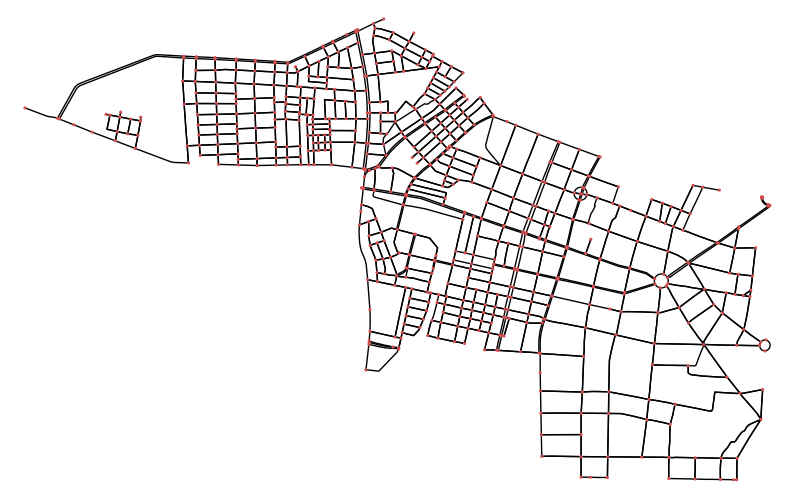

In [7]:
# [Cell 7] 下載並視覺化台南市中西區的路網模型，並標示出各個路口
import osmnx as ox
import matplotlib.pyplot as plt

print("正在從 OpenStreetMap 下載台南市中西區路網資料...")
print("(這可能需要幾十秒鐘，請稍候...)")

# 設定目標區域
place_name = "中西區, 台南市, 台灣"

# 下載路網圖 (network_type='drive' 代表只抓取汽車可通行的道路，會自動剃除純人行道)
# 這個 G 就是一個包含 Nodes 和 Edges 的數學圖論物件
G = ox.graph_from_place(place_name, network_type='drive')

print(f"✅ 下載完成！中西區共有 {len(G.nodes)} 個路口(Nodes)，{len(G.edges)} 條路段(Edges)。")

# 將路網視覺化畫出來
fig, ax = ox.plot_graph(
    G, 
    figsize=(10, 10),       # 設定圖片大小
    bgcolor="#ffffff",      # 背景顏色改為白色 (#ffffff)
    node_color="#D34F4F",   # 路口節點改為深灰色 (#333333)，確保在白底上清晰可見
    node_size=5,            # 節點大小
    edge_color="#000000",   # 路段改為黑色 (#000000)
    edge_linewidth=1        # 道路線條寬度
)

C:\Users\symba\AppData\Local\Temp\ipykernel_19612\3516554215.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  district_boundary = district_gdf.unary_union


✅ 成功過濾出 80 個位於中西區內的站牌。
✅ 已將站牌轉化為路網中的 75 個風險節點。


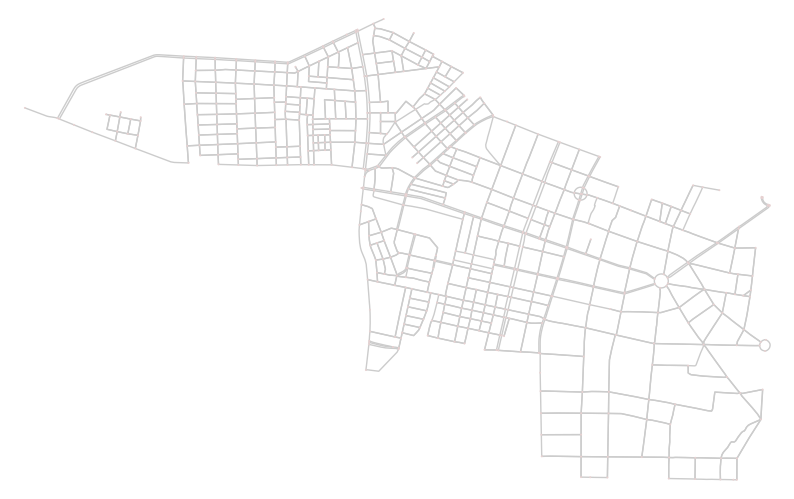

In [8]:
# [Cell 8] 取得中西區邊界，並將站牌座標精準對位至路網節點
import osmnx as ox
from shapely.geometry import Point

district_gdf = ox.geocode_to_gdf(place_name)
district_boundary = district_gdf.unary_union 

stop_coords = {}
if res_station.status_code == 200:
    for station in res_station.json():
        # 修正後的層級：直接從 StationPosition 抓取
        pos = station.get('StationPosition', {})
        lat, lon = pos.get('PositionLat'), pos.get('PositionLon')
        name = station.get('StationName', {}).get('Zh_tw')
        
        if name and lat and lon:
            # 幾何過濾：確保點在中西區行政區劃內
            point = Point(lon, lat)
            if point.within(district_boundary):
                stop_coords[name] = (lon, lat)
    
    print(f"✅ 成功過濾出 {len(stop_coords)} 個位於中西區內的站牌。")
else:
    print(f"❌ API 連線失敗，請檢查 Token。")

# 3. 空間對位：將站牌「吸附」到最近的路網節點 (Node)
stop_nodes = {}
if stop_coords:
    for stop_name, (lon, lat) in stop_coords.items():
        # 尋找路網 G 中最近的節點 ID
        nearest_node = ox.distance.nearest_nodes(G, X=lon, Y=lat)
        stop_nodes[stop_name] = nearest_node
    print(f"✅ 已將站牌轉化為路網中的 {len(set(stop_nodes.values()))} 個風險節點。")

# --- 繪圖驗證 ---
fig, ax = ox.plot_graph(G, figsize=(10, 10), bgcolor="#ffffff", node_color="#E8D2D2", 
                        node_size=2, edge_color="#cccccc", show=False, close=False)

# 將綁定後的節點畫成紅點 (這保證一定在地圖的線上/點上)
node_x = [G.nodes[n]['x'] for n in stop_nodes.values()]
node_y = [G.nodes[n]['y'] for n in stop_nodes.values()]

In [9]:
# [Cell 9] 接續 Cell 8，將 stop_coords 綁定到路網 G
import osmnx as ox

print("正在將公車站牌綁定到路網的真實路口...")
stop_nodes = {}

# 直接使用 Cell 8 產生的 stop_coords 字典
for stop_name, (lon, lat) in stop_coords.items():
    # 找出距離該經緯度最近的路口 Node ID
    nearest_node = ox.distance.nearest_nodes(G, X=lon, Y=lat)
    stop_nodes[stop_name] = nearest_node

print(f"✅ 成功綁定 {len(stop_nodes)} 個站牌！")
if '神農街' in stop_nodes:
    print(f"👉 【神農街】站對應的 Node ID: {stop_nodes['神農街']}")

正在將公車站牌綁定到路網的真實路口...
✅ 成功綁定 80 個站牌！
👉 【神農街】站對應的 Node ID: 1709220981


In [13]:
# [Cell 10] 將風險節點轉化為路網阻力 (Dynamic Weighting)

# 1. 初始化：所有路段預設權重 = 實際長度
for u, v, k, data in G.edges(keys=True, data=True):
    data['dynamic_cost'] = data['length']

# 2. 模擬風險：假設神農街目前有公車停靠
target_stop = '神農街'

if target_stop in stop_nodes:
    risk_node = stop_nodes[target_stop]
    # 設定一個極大的懲罰值 (例如 5000 公尺)，強迫演算法繞道
    penalty = 5000 
    
    # 找出所有連接到該風險路口的街道
    for u, v, k, data in G.edges(keys=True, data=True):
        if u == risk_node or v == risk_node:
            data['dynamic_cost'] += penalty
            
    print(f"🚨 風險觸發：【{target_stop}】節點已加上阻力懲罰 (+{penalty}m)")
else:
    print(f"⚠️ 找不到 {target_stop} 的對應節點，請確認 Cell 8 是否成功執行。")

🚨 風險觸發：【神農街】節點已加上阻力懲罰 (+5000m)


傳統路徑長度: 616.6 公尺
避險路徑長度: 616.6 公尺
⚠️ 警告：兩條路徑相同！這代表神農街周邊可能全是單行道，無路可繞。
🟠 橘色 X 為模擬的公車風險點


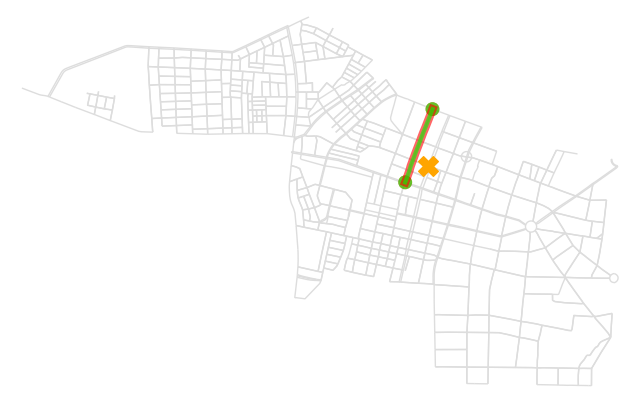

In [11]:
# [Cell 11 強化對決版]
import networkx as nx

# 重新選定一組「跨越神農街」的起終點
# 起點：海安路二段附近 / 終點：民權路三段附近
orig = ox.distance.nearest_nodes(G, X=120.1969, Y=23.0001) 
dest = ox.distance.nearest_nodes(G, X=120.1950, Y=22.9960)

try:
    # 🔴 計算傳統路徑
    route_trad = nx.shortest_path(G, orig, dest, weight='length')
    # 🟢 計算避險路徑
    route_safe = nx.shortest_path(G, orig, dest, weight='dynamic_cost')

    print(f"傳統路徑長度: {nx.path_weight(G, route_trad, 'length'):.1f} 公尺")
    print(f"避險路徑長度: {nx.path_weight(G, route_safe, 'length'):.1f} 公尺")

    if route_trad == route_safe:
        print("⚠️ 警告：兩條路徑相同！這代表神農街周邊可能全是單行道，無路可繞。")
    
    # --- 繪圖強化 ---
    # 同時畫出兩條路線，並設定 alpha 透明度，這樣重疊時會變色
    fig, ax = ox.plot_graph_routes(
        G, 
        routes=[route_trad, route_safe], 
        route_colors=['red', 'lime'], 
        route_linewidths=[6, 3], # 讓紅線粗一點，綠線細一點，重疊時紅邊會露出來
        route_alpha=0.6,
        node_size=0,
        bgcolor='#ffffff',
        edge_color='#dddddd',
        show=False,
        close=False
    )
    
    # 把我們設定風險的「紅點」也標上去，看綠線有沒有繞開它
    risk_node = stop_nodes['神農街']
    ax.scatter(G.nodes[risk_node]['x'], G.nodes[risk_node]['y'], c='orange', s=200, marker='X', label='Danger', zorder=5)
    
    print("🟠 橘色 X 為模擬的公車風險點")
    import matplotlib.pyplot as plt
    plt.show()

except Exception as e:
    print(f"❌ 錯誤: {e}")

In [14]:
# [安裝套件]
%pip install streamlit folium streamlit-folium

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.1 MB 2.3 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.1 MB 2.2 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/9.1 MB 2.5 MB/s eta 0:00:03
   ---------- ----------------------------- 2.4/9.1 MB 2.4 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/9.1 MB 2.3 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.1 MB 2.3 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/9.1 MB 2.3 MB/s eta 0:00:03
   ------------------- -------------------- 4.5/9.1 MB 2.4 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.1 MB 2.4 MB/s eta 0:00:02
   ----------------------- ---------------- 5.2/9.1 MB 2.4 MB/s eta 0:00:02
   ------------------------ --------------- 5.5/9.1 MB 2.3 MB/s eta 0:00:02
   -----------------------

  You can safely remove it manually.
  You can safely remove it manually.


In [15]:
%%writefile app.py
import streamlit as st
import osmnx as ox
import networkx as nx
import folium
from streamlit_folium import st_folium

# 1. 網頁標題與設定
st.set_page_config(page_title="Project Alley-Cat", layout="wide")
st.title("🐈 Project Alley-Cat：台南中西區微觀避險雷達")
st.markdown("這是一個結合圖論與即時動態的物流避險系統，能自動避開大客車與擁擠巷弄。")

# 2. 核心大腦：快取路網資料 (避免每次重整網頁都要重新下載)
@st.cache_resource
def load_graph():
    place_name = "中西區, 台南市, 台灣"
    # 下載地圖
    G = ox.graph_from_place(place_name, network_type='drive')
    
    # 加入路寬分級懲罰 (第一層物理阻力)
    hierarchy_penalty = {'primary': 1, 'secondary': 1.2, 'tertiary': 2, 'residential': 5, 'service': 10, 'unclassified': 3}
    for u, v, k, data in G.edges(keys=True, data=True):
        h_type = data.get('highway')
        if isinstance(h_type, list): h_type = h_type[0]
        data['dynamic_cost'] = data['length'] * hierarchy_penalty.get(h_type, 2)
        
    return G

# 載入地圖模型
with st.spinner("正在載入中西區路網模型..."):
    G = load_graph()

# 3. 側邊欄控制面板
st.sidebar.header("🕹️ 導航控制中心")
st.sidebar.markdown("請設定起始點與終點：")
# 為了測試方便，我們先預設好剛剛成功繞道的座標
start_lat = st.sidebar.number_input("起點緯度", value=23.0001, format="%.4f")
start_lon = st.sidebar.number_input("起點經度", value=120.1969, format="%.4f")
end_lat = st.sidebar.number_input("終點緯度", value=22.9960, format="%.4f")
end_lon = st.sidebar.number_input("終點經度", value=120.1950, format="%.4f")

activate_risk = st.sidebar.checkbox("🚨 模擬突發事件：神農街有公車停靠", value=True)

# 4. 運算路徑
orig = ox.distance.nearest_nodes(G, X=start_lon, Y=start_lat)
dest = ox.distance.nearest_nodes(G, X=end_lon, Y=end_lat)

# 如果勾選了突發事件，就把神農街附近的路口加上巨大阻力
risk_node = ox.distance.nearest_nodes(G, X=120.1970, Y=22.9985) # 神農街概略位置
if activate_risk:
    for u, v, k, data in G.edges(keys=True, data=True):
        if u == risk_node or v == risk_node:
            data['dynamic_cost'] += 10000

# 計算兩條路線
route_trad = nx.shortest_path(G, orig, dest, weight='length')
route_safe = nx.shortest_path(G, orig, dest, weight='dynamic_cost')

# 5. 繪製互動式地圖
m = folium.Map(location=[22.998, 120.196], zoom_start=15, tiles="CartoDB positron")

# 將傳統路徑 (紅色) 畫上地圖
trad_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_trad]
folium.PolyLine(trad_coords, color="red", weight=4, opacity=0.6, tooltip="傳統最短路徑").add_to(m)

# 將避險路徑 (綠色) 畫上地圖
safe_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_safe]
folium.PolyLine(safe_coords, color="lime", weight=6, opacity=0.9, tooltip="Alley-Cat 避險路徑").add_to(m)

# 標記起終點和風險點
folium.Marker([start_lat, start_lon], popup="起點", icon=folium.Icon(color="blue")).add_to(m)
folium.Marker([end_lat, end_lon], popup="終點", icon=folium.Icon(color="green")).add_to(m)
if activate_risk:
    folium.CircleMarker([G.nodes[risk_node]['y'], G.nodes[risk_node]['x']], radius=10, color="orange", fill=True, fill_color="orange", popup="⚠️ 風險區").add_to(m)

# 在網頁上顯示地圖
st_folium(m, width=800, height=600)

Writing app.py
